# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import astropy.units as u
import bces.bces as BCES

from astropy.table import Table, vstack
from scipy.optimize import curve_fit
from statistics import mean
from scipy.integrate import quad
from collections import Counter
from astropy.coordinates import SkyCoord
from scipy.stats import norm
from astropy.io import fits

In [2]:
catalog_dir = "/home/alab_student/Tim/Projects/Catalogs/"
outdir = "/home/alab_student/Tim/Projects/MeV_Blazars/Outputs/Figures/"

In [3]:
labels = ['FSRQ', 'BLL', 'BCU']
colors = ['blue', 'red', 'purple']

# Functions

In [4]:
def mask_catalog_by_class(catalog, class_column):
    fsrq_mask = [x in ['FSRQ','fsrq'] for x in catalog[class_column].tolist()]
    bll_mask = [x in ['BLL','bll'] for x in catalog[class_column].tolist()]
    bcu_mask = [x in ['BCU','bcu'] for x in catalog[class_column].tolist()]

    fsrq_masked_catalog = catalog[fsrq_mask]
    bll_masked_catalog = catalog[bll_mask]
    bcu_masked_catalog = catalog[bcu_mask]

    return fsrq_masked_catalog, bll_masked_catalog, bcu_masked_catalog

def line(x_data,m,c): 
    return m*x_data + c 

def weighted_average(values, errors):
    values = np.asarray(values, dtype=float)
    errors = np.asarray(errors, dtype=float)

    if np.any(errors <= 0):
        raise ValueError("All errors must be positive.")

    weights = 1.0 / errors**2
    mean = np.sum(weights * values) / np.sum(weights)
    mean_err = np.sqrt(1.0 / np.sum(weights))

    return mean, mean_err

# Catalogs

In [5]:
Peaked_MeV_Blazar_Catalog = Table.read(catalog_dir + 'Masked_Peaked_MeV_Blazar_Catalog.fits')
Peaked_MeV_FSRQ, Peaked_MeV_BLL, Peaked_MeV_BCU = mask_catalog_by_class(Peaked_MeV_Blazar_Catalog, 'Class')
Masked_Peaked_all = [Peaked_MeV_FSRQ, Peaked_MeV_BLL, Peaked_MeV_BCU]

Transition_MeV_Blazar_Catalog = Table.read(catalog_dir + 'Masked_Transition_MeV_Blazar_Catalog.fits')
Transition_MeV_FSRQ, Transition_MeV_BLL, Transition_MeV_BCU = mask_catalog_by_class(Transition_MeV_Blazar_Catalog, 'Class')
Masked_Transition_all = [Transition_MeV_FSRQ, Transition_MeV_BLL, Transition_MeV_BCU]

Masked_MeV_Blazar_Catalog = Table.read(catalog_dir + 'MeV_Blazars_Sample_Catalog.fits')
Masked_MeV_FSRQ, Masked_MeV_BLL, Masked_MeV_BCU = mask_catalog_by_class(Masked_MeV_Blazar_Catalog, 'Class')
Masked_Blazars_all = [Masked_MeV_FSRQ, Masked_MeV_BLL, Masked_MeV_BCU]

Firm_MeV_Blazar_Catalog = Table.read(catalog_dir + 'Firm_MeV_Blazar_Catalog.fits')
Firm_MeV_FSRQ, Firm_MeV_BLL, Firm_MeV_BCU = mask_catalog_by_class(Firm_MeV_Blazar_Catalog, 'Fermi Type')
Firm_Match_all = [Firm_MeV_FSRQ, Firm_MeV_BLL, Firm_MeV_BCU]

In [6]:
Counter(Firm_MeV_Blazar_Catalog['Swift Type'].tolist())

Counter({'BZB': 22,
         'Beamed AGN': 32,
         'FSRQ': 10,
         'BZG': 6,
         'BZQ': 44,
         'BZQ/Lense': 1})

# Firm Match

57
34
3


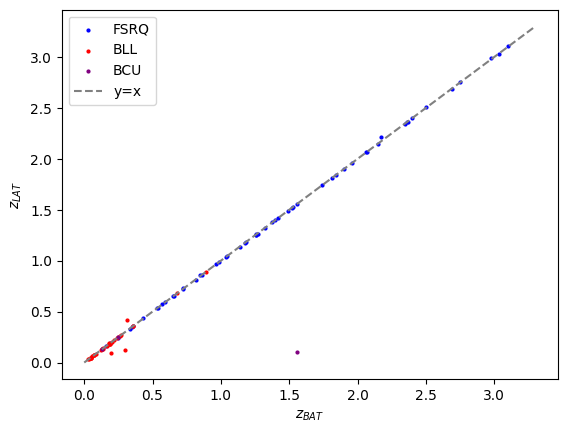

In [7]:
for i in range(len(Firm_Match_all)):
    Swift_Redshift = Firm_Match_all[i]['Swift Redshift'].tolist()
    Fermi_Redshift = Firm_Match_all[i]['Fermi Redshift'].tolist()
    
    Swift_Redshift_Masked = [float(Swift_Redshift[x]) for x in range(len(Swift_Redshift)) if Swift_Redshift[x] != 'None' and Fermi_Redshift[x] != 'None']
    Fermi_Redshift_Masked = [float(Fermi_Redshift[x]) for x in range(len(Swift_Redshift)) if Swift_Redshift[x] != 'None' and Fermi_Redshift[x] != 'None']
    print(len(Swift_Redshift_Masked))
    plt.scatter(Swift_Redshift_Masked, Fermi_Redshift_Masked, s=4,label=labels[i],color=colors[i])
    plt.xlabel(r'$z_{BAT}$')
    plt.ylabel(r'$z_{LAT}$')
    
plt.plot(np.linspace(0,3.3,100),np.linspace(0,3.3,100),linestyle='--',label='y=x',color='grey')
plt.legend(loc='upper left')

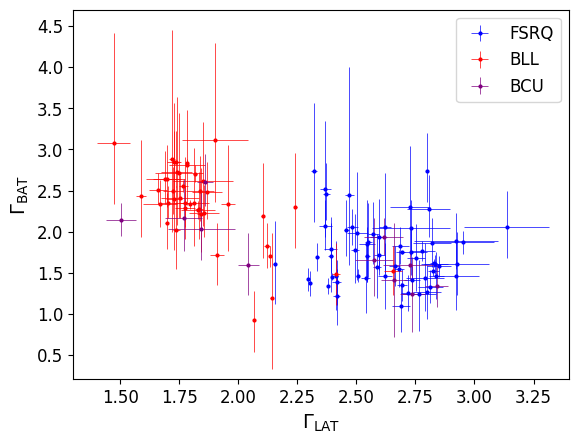

In [8]:
for i in range(len(Firm_Match_all)):
    BAT_index = Firm_Match_all[i]['Swift Photon Index'].tolist()
    BAT_index_err = Firm_Match_all[i]['Swift Photon Index Err'].tolist()
    
    BAT_index_errors = [[],[]]
    
    for x in range(len(BAT_index_err)):
        err_lo = BAT_index[x] - BAT_index_err[x][0]
        err_hi = BAT_index_err[x][1] - BAT_index[x] 
        BAT_index_errors[0].append(err_lo)
        BAT_index_errors[1].append(err_hi)
        
    Fermi_index = Firm_Match_all[i]['Fermi Photon Index'].tolist()
    Fermi_index_err = [0 if x == 'None' else float(x) for x in Firm_Match_all[i]['Fermi Photon Index Err'].tolist()]
    
    plt.errorbar( Fermi_index, BAT_index, yerr=BAT_index_errors, xerr=Fermi_index_err, fmt='o',markersize=2,elinewidth=0.5,color=colors[i],label=labels[i])
    plt.xlabel(r'$\Gamma_{\mathrm{LAT}}$', fontsize=14)
    plt.ylabel(r'$\Gamma_{\mathrm{BAT}}$', fontsize=14)

#plt.plot(np.linspace(1,3.5,100),np.linspace(1,3.5,100),color='grey',linestyle='--',label='x=y')
plt.xlim(1.3,3.4)
plt.ylim(0.2,4.7)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', labelsize=12)

plt.savefig(outdir + 'LAT_BAT_index_comparison.pdf', dpi=300,bbox_inches='tight')
        

In [9]:
print(Firm_Match_all[0].colnames)

['id', 'Match Flag', 'Fermi Counterpart Name', 'Swift Counterpart Name', 'Fermi Type', 'Swift Type', 'SED Class', 'Fermi RA', 'Fermi DEC', 'Swift RA', 'Swift DEC', 'Fermi Redshift', 'Swift Redshift', 'Fermi Photon Index', 'Fermi Photon Index Err', 'Swift Photon Index', 'Swift Photon Index Err', 'Log Swift Luminosity', 'Syn Peak Energy', 'Syn Peak Flux', 'Energy', 'Energy Flux', 'Energy Flux Err']


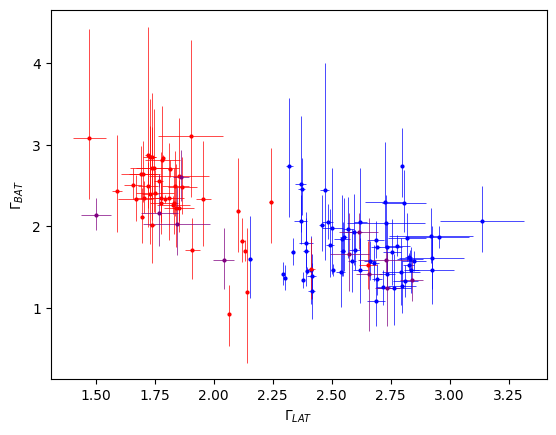

In [10]:
for i in range(len(Firm_Match_all)):
    BAT_index = Firm_Match_all[i]['Swift Photon Index'].tolist()
    BAT_index_err = Firm_Match_all[i]['Swift Photon Index Err'].tolist()
    
    BAT_index_errors = [[],[]]
    
    for x in range(len(BAT_index_err)):
        err_lo = BAT_index[x] - BAT_index_err[x][0]
        err_hi = BAT_index_err[x][1] - BAT_index[x] 
        BAT_index_errors[0].append(err_lo)
        BAT_index_errors[1].append(err_hi)
        
    Fermi_index = Firm_Match_all[i]['Fermi Photon Index'].tolist()
    Fermi_index_err = [0 if x == 'None' else float(x) for x in Firm_Match_all[i]['Fermi Photon Index Err'].tolist()]
    
    plt.errorbar( Fermi_index, BAT_index, yerr=BAT_index_errors, xerr=Fermi_index_err, fmt='o',markersize=2,elinewidth=0.5,color=colors[i],label=labels[i])
    plt.xlabel(r'$\Gamma_{LAT}$')
    plt.ylabel(r'$\Gamma_{BAT}$')

In [11]:
Firm_MeV_Blazar_Catalog.pprint_all()

 id Match Flag  Fermi Counterpart Name   Swift Counterpart Name   Fermi Type Swift Type SED Class      Fermi RA           Fermi DEC      Swift RA Swift DEC    Fermi Redshift    Swift Redshift Fermi Photon Index Fermi Photon Index Err Swift Photon Index Swift Photon Index Err Log Swift Luminosity    Syn Peak Energy         Syn Peak Flux                        Energy                                    Energy Flux                                    Energy Flux Err                
                                                                                                         deg                 deg           deg       deg                                                                                                                                  erg / s                 MeV               MeV / (s cm2)                         MeV                                     MeV / (s cm2)                                    MeV / (s cm2)                 
--- ---------- ---------------------

3.1040000915527344
6
0
0


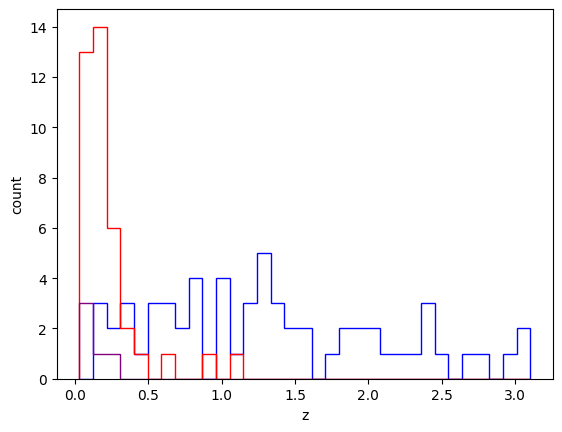

In [34]:
Fermi_Redshift_all = [float(x) for x in Firm_MeV_Blazar_Catalog['Fermi Redshift'].tolist() if x != 'None']
print(max(Fermi_Redshift_all))
Bins = np.linspace(min(Fermi_Redshift_all), max(Fermi_Redshift_all), 34)

for i in range(len(Firm_Match_all)):
    Swift_Redshift = Firm_Match_all[i]['Swift Redshift'].tolist()
    Fermi_Redshift = Firm_Match_all[i]['Fermi Redshift'].tolist()
    
    Redshift = [Swift_Redshift[x] if Fermi_Redshift[x] == 'None' else Fermi_Redshift[x] for x in range(len(Fermi_Redshift))]
    Redshift = [float(x) for x in Redshift if x != 'None']
    print(len([x for x in Redshift if x >= 2.5]))
    
    plt.hist(Redshift, Bins, histtype='step',color=colors[i],label=f"{labels[i]}: ({len(Redshift)})")
    plt.xlabel(r'z')
    plt.ylabel('count')

# Distributions

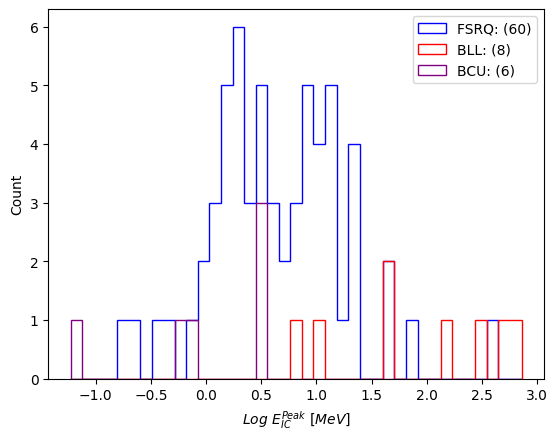

In [13]:
IC_peaks_all = [np.log10(float(x)) for x in Peaked_MeV_Blazar_Catalog['IC_Peak_Energy'].tolist()]
MeV_IC_Peak_mask = [x <= 2 and x >= -1 for x in IC_peaks_all]

MeV_Peaked_sources = Peaked_MeV_Blazar_Catalog[MeV_IC_Peak_mask]

Bins = np.linspace(min(IC_peaks_all), max(IC_peaks_all), 40)

for i in range(len(Masked_Peaked_all)):
    IC_Peak_Energy = [np.log10(float(x)) for x in Masked_Peaked_all[i]['IC_Peak_Energy'].tolist()]
    plt.hist(IC_Peak_Energy, Bins,histtype='step',color=colors[i],label=f"{labels[i]}: ({len(IC_Peak_Energy)})")
    plt.xlabel(r'$Log$ $E^{Peak}_{IC}$ $[MeV]$')
    plt.ylabel('Count')

plt.legend()

In [14]:
LAT_LP_Index = MeV_Peaked_sources['LAT_LP_Index'].tolist()
print(min(LAT_LP_Index))

BAT_index = MeV_Peaked_sources['BAT_Index'].tolist()
MeV_Peaked_sources.pprint_all()

2.0734169483184814
          Name          Class SED_Class       Redshift      BAT_Index BAT_Index_err    LAT_PL_Index       LAT_PL_Index_err      MeV_PL_Index       MeV_PL_Index_err      LAT_LP_Index      LAT_LP_Index_err      MeV_LP_Index       MeV_LP_Index_err       MeV_LP_Beta         MeV_LP_Beta_err      MeV_BPL_Index1     MeV_BPL_Index1_err    MeV_BPL_Index2     MeV_BPL_Index2_err      SED_Alpha          SED_Alpha_err           SED_Beta            SED_Beta_err           X_Ray_Flux         X_Ray_Flux_err_lo      X_Ray_Flux_err_hi           GeV_Flux             GeV_Flux_err           MeV_PL_Flux          MeV_PL_Flux_err          MeV_LP_Flux          MeV_LP_Flux_err          MeV_BPL_Flux         MeV_BPL_Flux_err    Best_Model    Syn_Peak_Energy      Syn_Peak_Energy_Flux  LAT_HE_Peak_Energy LAT_HE_Peak_Energy_err    IC_Peak_Energy    IC_Peak_Energy_err  IC_Peak_Energy_Flux   IC_Peak_Energy_Flux_err SBPL_IC_Peak_Energy   MeV_Luminosity     MeV_Luminosity_err  SMBH_Mass SMBH_Mass_Err  

Text(0, 0.5, 'count')

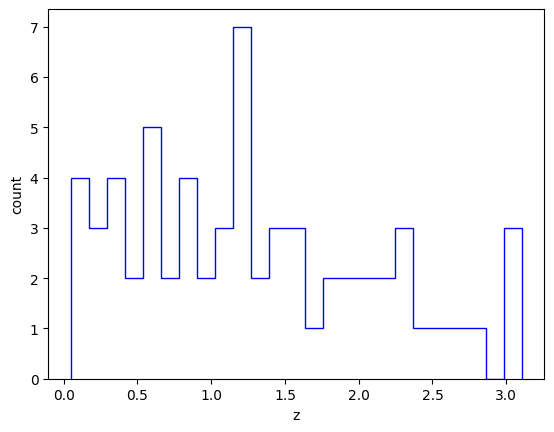

In [15]:
MeV_Peaked_Redshift = [float(x) for x in MeV_Peaked_sources['Redshift'].tolist() if x != 'None']
bins = 25
plt.hist(MeV_Peaked_Redshift,bins,histtype='step',color='blue')
plt.xlabel(r'z')
plt.ylabel('count')

70
61


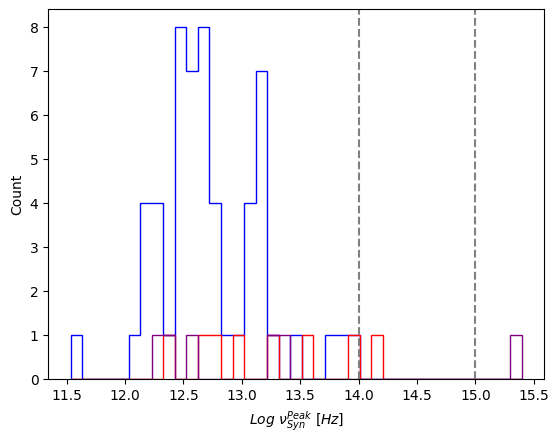

In [16]:
Syn_peaks_all = [np.log10(x * 2.417 * 1e20) for x in Peaked_MeV_Blazar_Catalog['Syn_Peak_Energy'].tolist() if x != None]
print(len(Syn_peaks_all))
print(len([x for x in Syn_peaks_all if x >= 12 and x <= 13.4]))
Bins = np.linspace(min(Syn_peaks_all), max(Syn_peaks_all), 40)

for i in range(len(Masked_Peaked_all)):
    Syn_peaks = [np.log10(x * 2.417 * 1e20) for x in Masked_Peaked_all[i]['Syn_Peak_Energy'].tolist() if x != None]
    
    plt.hist(Syn_peaks, Bins, histtype='step', color=colors[i],label=f"{labels[i]} ({len(Syn_peaks)})")
    plt.xlabel(r'$Log$ $\nu^{Peak}_{Syn}$ $[Hz]$')
    plt.ylabel('Count')
    
plt.axvline(14, linestyle='--',color='grey')
plt.axvline(15, linestyle='--',color='grey')

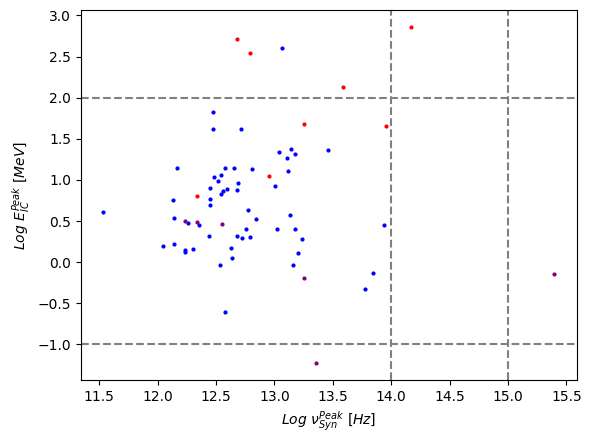

In [17]:
for i in range(len(Masked_Peaked_all)):
    Syn_peaks = [np.log10(x * 2.417 * 1e20) for x in Masked_Peaked_all[i]['Syn_Peak_Energy'].tolist() if x != None]
    
    IC_Peak_Energy = [np.log10(float(x)) for x in Masked_Peaked_all[i]['IC_Peak_Energy'].tolist()]
    IC_Peak_Energy = [IC_Peak_Energy[x] for x in range(len(Masked_Peaked_all[i]['Syn_Peak_Energy'].tolist())) if Masked_Peaked_all[i]['Syn_Peak_Energy'].tolist()[x] != None]
    plt.errorbar(Syn_peaks, IC_Peak_Energy, color=colors[i],fmt='o', label=f"{labels[i]} ({len(Syn_peaks)})",markersize=2)
    plt.xlabel(r'$Log$ $\nu^{Peak}_{Syn}$ $[Hz]$')
    plt.ylabel(r'$Log$ $E^{Peak}_{IC}$ $[MeV]$')
    
plt.axvline(14, linestyle='--',color='grey')
plt.axvline(15, linestyle='--',color='grey')

plt.axhline(-1, linestyle='--',color='grey')
plt.axhline(2, linestyle='--',color='grey')

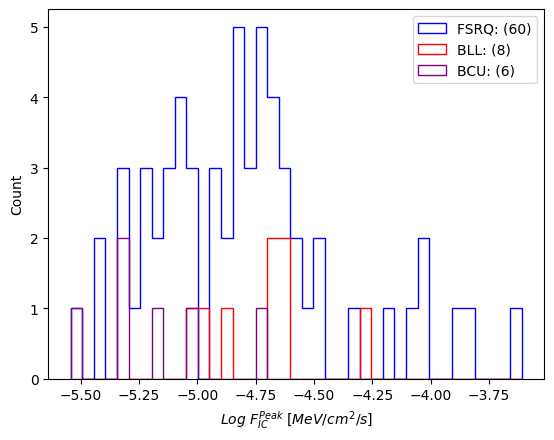

In [18]:
IC_peak_flux_all = [np.log10(float(x)) for x in Peaked_MeV_Blazar_Catalog['IC_Peak_Energy_Flux'].tolist()]
Bins = np.linspace(min(IC_peak_flux_all), max(IC_peak_flux_all), 40)

for i in range(len(Masked_Peaked_all)):
    IC_Peak_Energy_Flux = [np.log10(float(x)) for x in Masked_Peaked_all[i]['IC_Peak_Energy_Flux'].tolist()]
    plt.hist(IC_Peak_Energy_Flux, Bins,histtype='step',color=colors[i],label=f"{labels[i]}: ({len(IC_Peak_Energy_Flux)})")
    plt.xlabel(r'$Log$ $F^{Peak}_{IC}$ $[MeV/cm^{2}/s]$')
    plt.ylabel('Count')

plt.legend()

In [19]:
Masked_MeV_Blazar_Catalog.pprint_all()

          Name          Class SED_Class       Redshift       BAT_Index BAT_Index_err    LAT_PL_Index       LAT_PL_Index_err      MeV_PL_Index       MeV_PL_Index_err      LAT_LP_Index      LAT_LP_Index_err      MeV_LP_Index       MeV_LP_Index_err        MeV_LP_Beta          MeV_LP_Beta_err       MeV_BPL_Index1     MeV_BPL_Index1_err    MeV_BPL_Index2     MeV_BPL_Index2_err       SED_Alpha          SED_Alpha_err            SED_Beta             SED_Beta_err           X_Ray_Flux         X_Ray_Flux_err_lo      X_Ray_Flux_err_hi           GeV_Flux             GeV_Flux_err           MeV_PL_Flux          MeV_PL_Flux_err          MeV_LP_Flux          MeV_LP_Flux_err          MeV_BPL_Flux         MeV_BPL_Flux_err    Best_Model    Syn_Peak_Energy      Syn_Peak_Energy_Flux  LAT_HE_Peak_Energy LAT_HE_Peak_Energy_err    IC_Peak_Energy     IC_Peak_Energy_err   IC_Peak_Energy_Flux   IC_Peak_Energy_Flux_err SBPL_IC_Peak_Energy   MeV_Luminosity     MeV_Luminosity_err  SMBH_Mass SMBH_Mass_Err       SED_C

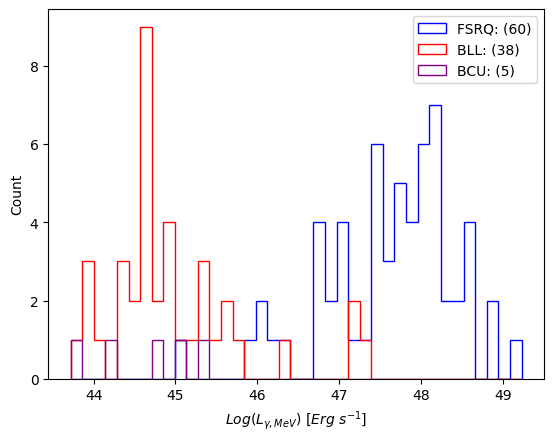

In [20]:
Luminosity_all = [float(x) for x in Masked_MeV_Blazar_Catalog['MeV_Luminosity'].tolist() if x != 'None']
Bins = np.linspace(min(Luminosity_all),max(Luminosity_all),40)

for i in range(len(Masked_Blazars_all)):
    Luminosity = Masked_Blazars_all[i]['MeV_Luminosity'].tolist()
    Luminosity = [float(x) for x in Luminosity if x != 'None']
    plt.hist(Luminosity,Bins,histtype='step',color=colors[i],label=f"{labels[i]}: ({len(Luminosity)})")
    plt.xlabel(r'$Log(L_{\gamma, MeV})$ [$Erg$ $s^{-1}$]')
    plt.ylabel('Count')
    
plt.legend()

# Correlations

BCES (Y|X): slope = -2.677 ± 0.250, intercept = 7.576 ± 0.634


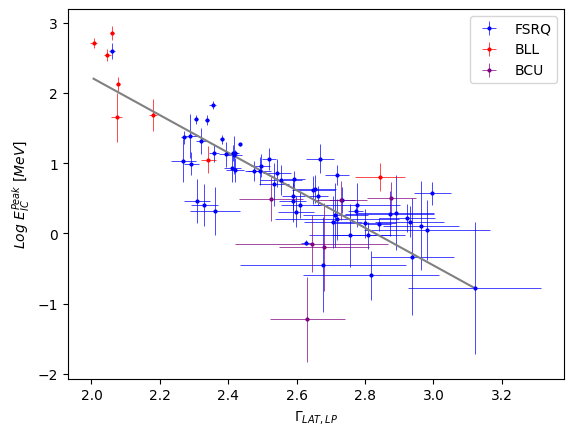

In [21]:
# Flatten arrays
LAT_LP_gamma_all = np.array(Peaked_MeV_Blazar_Catalog['LAT_LP_Index'].tolist(), dtype=float)
LAT_LP_gamma_err_all = np.array(Peaked_MeV_Blazar_Catalog['LAT_LP_Index_err'].tolist(), dtype=float)

IC_peak_energy_all = np.array(Peaked_MeV_Blazar_Catalog['IC_Peak_Energy'].tolist(), dtype=float)
IC_peak_energy_log_all = np.log10(IC_peak_energy_all)
IC_peak_energy_err_all = np.array(Peaked_MeV_Blazar_Catalog['IC_Peak_Energy_err'].tolist(), dtype=float)
IC_peak_energy_err_log_all = np.abs((1 / np.log(10)) * (IC_peak_energy_err_all / IC_peak_energy_all))

# Plot individual subsets
for i in range(len(Masked_Peaked_all)):
    LAT_gammas = np.array(Masked_Peaked_all[i]['LAT_LP_Index'].tolist(), dtype=float)
    LAT_gammas_err = np.array(Masked_Peaked_all[i]['LAT_LP_Index_err'].tolist(), dtype=float)
    IC_peak_energy = np.array(Masked_Peaked_all[i]['IC_Peak_Energy'].tolist(), dtype=float)
    IC_peak_energy_err = np.array(Masked_Peaked_all[i]['IC_Peak_Energy_err'].tolist(), dtype=float)
    IC_peak_energy_log = np.log10(IC_peak_energy)
    IC_peak_energy_err_log = np.abs((1 / np.log(10)) * (IC_peak_energy_err / IC_peak_energy))

    plt.errorbar(LAT_gammas, IC_peak_energy_log, xerr=LAT_gammas_err, yerr=IC_peak_energy_err_log, fmt='o', markersize=2, elinewidth=0.5, color=colors[i], label=labels[i])

plt.xlabel(r'$\Gamma_{LAT,LP}$')
plt.ylabel(r'$Log$ $E^{Peak}_{IC}$ $[MeV]$')
plt.legend()

# --- BCES Y|X regression ---
cov = np.zeros_like(LAT_LP_gamma_all)  # assuming x and y errors uncorrelated
a, b, aerr, berr, covab = BCES.bces(LAT_LP_gamma_all, LAT_LP_gamma_err_all, IC_peak_energy_log_all, IC_peak_energy_err_log_all, cov)

# BCES Y|X results:
slope = a[0]
intercept = b[0]
slope_err = aerr[0]
intercept_err = berr[0]

print(f"BCES (Y|X): slope = {slope:.3f} ± {slope_err:.3f}, intercept = {intercept:.3f} ± {intercept_err:.3f}")

# --- Plot BCES best-fit line ---
x_line = np.linspace(min(LAT_LP_gamma_all), max(LAT_LP_gamma_all), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='grey', linestyle='-')

plt.savefig(outdir + 'BCES_Linear_Regression_E_Gamma.png',dpi=300,bbox_inches='tight')

plt.show()

Peaked BCES (Y|X): slope = 0.475 ± 0.056, intercept = -1.832 ± 0.287
Transition BCES (Y|X): slope = 0.557 ± 0.083, intercept = -2.367 ± 0.428


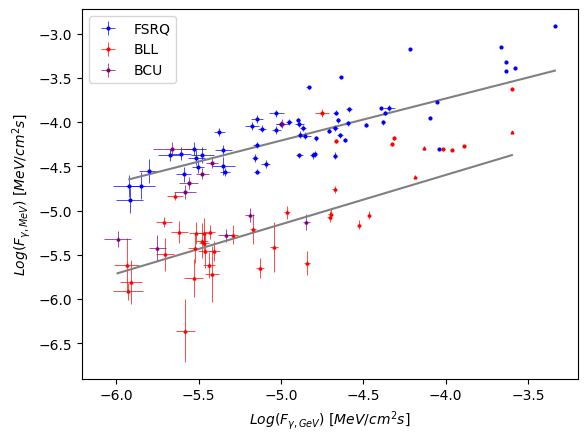

In [22]:
Peaked_MeV_Flux_log_all = []
Peaked_GeV_Flux_log_all = []
Peaked_MeV_Flux_err_log_all = []
Peaked_GeV_Flux_err_log_all = []

for i in range(len(Masked_Peaked_all)):
    GeV_Flux = Masked_Peaked_all[i]['GeV_Flux'].tolist()
    GeV_Flux_log = [np.log10(x) for x in Masked_Peaked_all[i]['GeV_Flux'].tolist()]
    GeV_Flux_err = Masked_Peaked_all[i]['GeV_Flux_err'].tolist()
    GeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(GeV_Flux_err, GeV_Flux)]

    MeV_Flux_all = Masked_Peaked_all[i]['MeV_LP_Flux'].tolist()
            
    MeV_Flux_err_all = Masked_Peaked_all[i]['MeV_LP_Flux_err'].tolist()

    MeV_Flux_log = [np.log10(x) for x in MeV_Flux_all]
    MeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(MeV_Flux_err_all, MeV_Flux_all)]
    Peaked_MeV_Flux_log_all.append(MeV_Flux_log)
    
    Peaked_GeV_Flux_log_all.append(GeV_Flux_log)
    Peaked_MeV_Flux_err_log_all.append(MeV_Flux_err_log)
    Peaked_GeV_Flux_err_log_all.append(GeV_Flux_err_log)

    plt.errorbar(GeV_Flux_log,MeV_Flux_log,xerr=GeV_Flux_err_log,yerr=MeV_Flux_err_log,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$Log(F_{\gamma, GeV})$ $[MeV/cm^{2} s]$')
    plt.ylabel(r'$Log(F_{\gamma, MeV})$ $[MeV/cm^{2} s]$')
    plt.legend()

Peaked_MeV_Flux_log_all = np.array(Peaked_MeV_Flux_log_all[0] + Peaked_MeV_Flux_log_all[1] + Peaked_MeV_Flux_log_all[2])
Peaked_GeV_Flux_log_all = np.array(Peaked_GeV_Flux_log_all[0] + Peaked_GeV_Flux_log_all[1] + Peaked_GeV_Flux_log_all[2])
Peaked_MeV_Flux_err_log_all = np.array(Peaked_MeV_Flux_err_log_all[0] + Peaked_MeV_Flux_err_log_all[1] + Peaked_MeV_Flux_err_log_all[2])
Peaked_GeV_Flux_err_log_all = np.array(Peaked_GeV_Flux_err_log_all[0] + Peaked_GeV_Flux_err_log_all[1] + Peaked_GeV_Flux_err_log_all[2])

cov = np.zeros_like(Peaked_GeV_Flux_log_all)  # assuming x and y errors uncorrelated
a, b, aerr, berr, covab = BCES.bces(Peaked_GeV_Flux_log_all, Peaked_GeV_Flux_err_log_all, Peaked_MeV_Flux_log_all, Peaked_MeV_Flux_err_log_all, cov)

# BCES Y|X results:
slope = a[0]
intercept = b[0]
slope_err = aerr[0]
intercept_err = berr[0]

print(f"Peaked BCES (Y|X): slope = {slope:.3f} ± {slope_err:.3f}, intercept = {intercept:.3f} ± {intercept_err:.3f}")

# --- Plot BCES best-fit line ---
x_line = np.linspace(min(Peaked_GeV_Flux_log_all), max(Peaked_GeV_Flux_log_all), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='grey', linestyle='-')

Transition_MeV_Flux_log_all = []
Transition_GeV_Flux_log_all = []
Transition_MeV_Flux_err_log_all = []
Transition_GeV_Flux_err_log_all = []

for i in range(len(Masked_Transition_all)):
    GeV_Flux = Masked_Transition_all[i]['GeV_Flux'].tolist()
    GeV_Flux_log = [np.log10(x) for x in Masked_Transition_all[i]['GeV_Flux'].tolist()]
    GeV_Flux_err = Masked_Transition_all[i]['GeV_Flux_err'].tolist()
    GeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(GeV_Flux_err, GeV_Flux)]

    MeV_Flux_all = Masked_Transition_all[i]['MeV_BPL_Flux'].tolist()
            
    MeV_Flux_err_all = Masked_Transition_all[i]['MeV_BPL_Flux_err'].tolist()

    MeV_Flux_log = [np.log10(x) for x in MeV_Flux_all]
    MeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(MeV_Flux_err_all, MeV_Flux_all)]
    Transition_MeV_Flux_log_all.append(MeV_Flux_log)
    
    Transition_GeV_Flux_log_all.append(GeV_Flux_log)
    Transition_MeV_Flux_err_log_all.append(MeV_Flux_err_log)
    Transition_GeV_Flux_err_log_all.append(GeV_Flux_err_log)

    plt.errorbar(GeV_Flux_log,MeV_Flux_log,xerr=GeV_Flux_err_log,yerr=MeV_Flux_err_log,fmt='^',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$Log(F_{\gamma, GeV})$ $[MeV/cm^{2} s]$')
    plt.ylabel(r'$Log(F_{\gamma, MeV})$ $[MeV/cm^{2} s]$')


Transition_MeV_Flux_log_all = np.array(Transition_MeV_Flux_log_all[0] + Transition_MeV_Flux_log_all[1] + Transition_MeV_Flux_log_all[2])
Transition_GeV_Flux_log_all = np.array(Transition_GeV_Flux_log_all[0] + Transition_GeV_Flux_log_all[1] + Transition_GeV_Flux_log_all[2])
Transition_MeV_Flux_err_log_all = np.array(Transition_MeV_Flux_err_log_all[0] + Transition_MeV_Flux_err_log_all[1] + Transition_MeV_Flux_err_log_all[2])
Transition_GeV_Flux_err_log_all = np.array(Transition_GeV_Flux_err_log_all[0] + Transition_GeV_Flux_err_log_all[1] + Transition_GeV_Flux_err_log_all[2])

cov = np.zeros_like(Transition_GeV_Flux_log_all)  # assuming x and y errors uncorrelated
a, b, aerr, berr, covab = BCES.bces(Transition_GeV_Flux_log_all, Transition_GeV_Flux_err_log_all, Transition_MeV_Flux_log_all, Transition_MeV_Flux_err_log_all, cov)

# BCES Y|X results:
slope = a[0]
intercept = b[0]
slope_err = aerr[0]
intercept_err = berr[0]

print(f"Transition BCES (Y|X): slope = {slope:.3f} ± {slope_err:.3f}, intercept = {intercept:.3f} ± {intercept_err:.3f}")

# --- Plot BCES best-fit line ---
x_line = np.linspace(min(Transition_GeV_Flux_log_all), max(Transition_GeV_Flux_log_all), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='grey', linestyle='-')

plt.savefig(outdir + 'BCES_MeV_GeV_Flux_reg.png', dpi=300, bbox_inches='tight')
plt.show()

0.6352867872811585 6.210614005802438 6.484616488222628e-08 5.4048955636722695
BCES (Y|X): slope = 0.442 ± 0.067, intercept = -12.103 ± 3.160


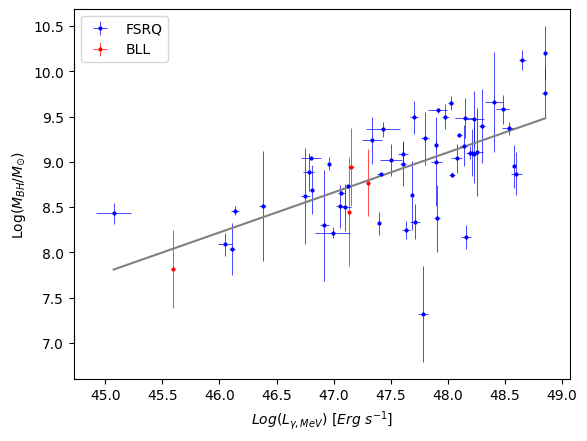

In [23]:
masked_lum_mass = [(float(a), float(b), float(c), float(d)) for a, b, c, d in zip(Peaked_MeV_Blazar_Catalog['SMBH_Mass'].tolist(), Peaked_MeV_Blazar_Catalog['SMBH_Mass_Err'].tolist(), Peaked_MeV_Blazar_Catalog['MeV_Luminosity'].tolist(), Peaked_MeV_Blazar_Catalog['MeV_Luminosity_err'].tolist()) if a != 'None' and b != 'None']
masked_mass_all, masked_mass_err_all, masked_luminosity_all, masked_luminosity_err_all = zip(*masked_lum_mass)

masked_luminosity_all = np.array(list(masked_luminosity_all))
masked_luminosity_err_all = np.array(list(masked_luminosity_err_all))
masked_mass_all = np.array(list(masked_mass_all))
masked_mass_err_all = np.array(list(masked_mass_err_all))
#print(masked_luminosity_all)
#print(masked_mass_all)

for i in range(len(Masked_Peaked_all)):
    Mass = Masked_Peaked_all[i]['SMBH_Mass'].tolist()
    Mass_err = Masked_Peaked_all[i]['SMBH_Mass_Err'].tolist()
    Luminosity = Masked_Peaked_all[i]['MeV_Luminosity'].tolist()
    Luminosity_err = Masked_Peaked_all[i]['MeV_Luminosity_err'].tolist()

    masked_results = [(float(c), float(d), float(a), float(b)) for a, b, c, d in zip(Mass, Mass_err, Luminosity, Luminosity_err) if a != 'None' and c != 'None']

    if len(masked_results) != 0:
        masked_luminosity, masked_luminosity_err, masked_mass, masked_mass_err = zip(*masked_results)

        masked_luminosity = list(masked_luminosity)
        masked_luminosity_err = list(masked_luminosity_err)
        masked_mass = list(masked_mass)
        masked_mass_err = list(masked_mass_err)

        plt.errorbar(masked_luminosity, masked_mass, xerr=masked_luminosity_err, yerr=masked_mass_err, fmt='o', markersize=2, color=colors[i], label=labels[i], elinewidth=0.5)
        #print(len(masked_luminosity))
        plt.xlabel(r'$Log(L_{\gamma, MeV})$ [$Erg$ $s^{-1}$]')
        plt.ylabel(r'Log($M_{BH}$/$M_{\odot}$)')
        plt.legend()
        
# --- BCES Y|X regression ---
cov = np.zeros_like(masked_luminosity_all)  # assuming x and y errors uncorrelated
a, b, aerr, berr, covab = BCES.bces(masked_luminosity_all, masked_luminosity_err_all, masked_mass_all, masked_mass_err_all, cov)

r = np.corrcoef(masked_luminosity_all, masked_mass_all)[0,1]
t = r * ((len(masked_luminosity_all) - 2) / (1 - r**2))**0.5
p = 2 * (1 - stats.t.cdf(abs(t), df=len(masked_luminosity_all)-2))
sigma = norm.isf(p/2)
print(r, t, p, sigma)

# BCES Y|X results:
slope = a[0]
intercept = b[0]
slope_err = aerr[0]
intercept_err = berr[0]

print(f"BCES (Y|X): slope = {slope:.3f} ± {slope_err:.3f}, intercept = {intercept:.3f} ± {intercept_err:.3f}")

# --- Plot BCES best-fit line ---
x_line = np.linspace(min(masked_luminosity_all), max(masked_luminosity_all), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='grey', linestyle='-')
plt.savefig(outdir + 'BCES_SMBH_mass_lum_reg.png',dpi=300,bbox_inches='tight')

# Blazar Sequence

[0.18834475106601964, 0.9354037395045763, 0.2364426375610765, 0.17206317453944261, 0.0995384184949682, 0.6510090425586565, 0.44367938079846203, 0.2857835635831127, 0.24895389998380965, 0.32017409811256736, 0.7134550520255569, 0.31323302440985196, 0.142792463399171, 1.4310209937824452, 2.274412212676521, 0.17225769496257173, 1.0663688698599278, 0.29099373222326846, 0.3553359096891513, 1.157405628822189, 5.934383951757695, 0.7376957129050697, 0.04421194632182747, 0.4556694305611583, 0.07080203699413347, 0.2863362546254261, 0.0374996573896606, 0.17612145011512648, 0.29590473731904543, 1.7430543459080243, 0.044660469541642205, 0.21869198045387406, 0.029430787378531168, 0.21907981192628684, 1.282133336275617, 0.14861300702098568, 0.03488101536850905, 0.6908904477748599, 0.1926123608374955, 0.1584515632823315, 0.7107570012584706, 0.15938329323175532, 0.7655404641039252, 0.15997455865715318, 0.042756914653882074, 0.019161409575438822, 0.3819620146288181, 15.857694984476073, 1.800548606163234,

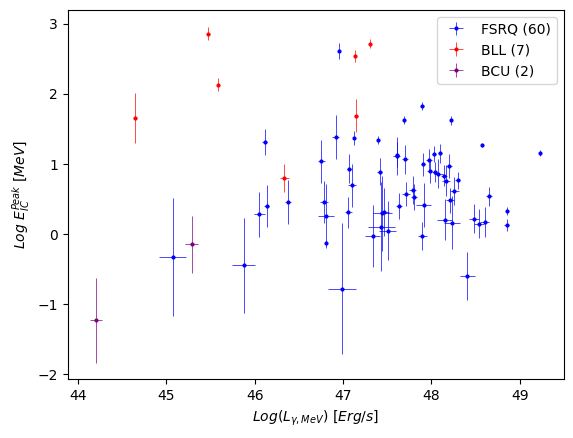

In [24]:
for i in range(len(Masked_Peaked_all)):
    IC_Peak_Energy = [float(x) for x in Masked_Peaked_all[i]['IC_Peak_Energy'].tolist()]
    IC_Peak_Energy_err = [float(x) for x in Masked_Peaked_all[i]['IC_Peak_Energy_err'].tolist()]
    
    IC_Peak_Energy_log = [np.log10(x) for x in IC_Peak_Energy]
    IC_Peak_Energy_err_log = [np.abs((1 / np.log(10)) * (x / y)) for x,y in zip(IC_Peak_Energy_err, IC_Peak_Energy)]
    

    Luminosity = Masked_Peaked_all[i]['MeV_Luminosity'].tolist()
    Luminosity_err = Masked_Peaked_all[i]['MeV_Luminosity_err'].tolist()
    
    IC_Peak_Energy_log_masked = [float(IC_Peak_Energy_log[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    IC_Peak_Energy_err_log_masked = [float(IC_Peak_Energy_err_log[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    Luminosity_err_masked = [float(Luminosity_err[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    Luminosity_masked = [float(Luminosity[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']

    Rel_err = [np.abs(x / y) for x,y in zip(IC_Peak_Energy_err_log_masked, IC_Peak_Energy_log_masked)]
    print(Rel_err)
    for x in range(len(Rel_err)):
        if Rel_err[x] > 0.5:
            print(f"High relative error: {Rel_err[x]}, {Luminosity_masked[x]}, {IC_Peak_Energy_log_masked[x]}")
    
    plt.errorbar(Luminosity_masked, IC_Peak_Energy_log_masked, xerr=Luminosity_err_masked,yerr=IC_Peak_Energy_err_log_masked,color=colors[i],label=f"{labels[i]} ({len(Luminosity_masked)})",elinewidth=0.5,fmt='o',markersize=2)
    plt.ylabel(r'$Log$ $E^{Peak}_{IC}$ $[MeV]$')
    plt.xlabel(r'$Log(L_{\gamma, MeV})$ $[Erg/s]$')
    
    plt.legend()
    
plt.savefig(outdir + 'Sequence_IC_peak.png',bbox_inches='tight',dpi=300)

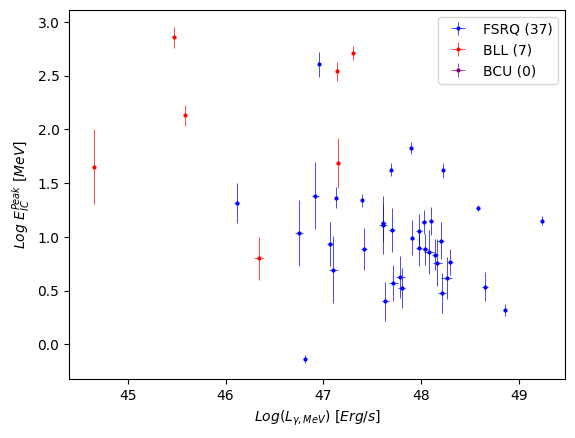

In [25]:
for i in range(len(Masked_Peaked_all)):
    IC_Peak_Energy = [float(x) for x in Masked_Peaked_all[i]['IC_Peak_Energy'].tolist()]
    IC_Peak_Energy_err = [float(x) for x in Masked_Peaked_all[i]['IC_Peak_Energy_err'].tolist()]
    
    IC_Peak_Energy_log = [np.log10(x) for x in IC_Peak_Energy]
    IC_Peak_Energy_err_log = [np.abs((1 / np.log(10)) * (x / y)) for x,y in zip(IC_Peak_Energy_err, IC_Peak_Energy)]
    
    

    Luminosity = Masked_Peaked_all[i]['MeV_Luminosity'].tolist()
    Luminosity_err = Masked_Peaked_all[i]['MeV_Luminosity_err'].tolist()
    
    IC_Peak_Energy_log_masked = [float(IC_Peak_Energy_log[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    IC_Peak_Energy_err_log_masked = [float(IC_Peak_Energy_err_log[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    Luminosity_err_masked = [float(Luminosity_err[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    Luminosity_masked = [float(Luminosity[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']

    Rel_err = [np.abs(x / y) for x,y in zip(IC_Peak_Energy_err_log_masked, IC_Peak_Energy_log_masked)]

    IC_Peak_Energy_log_double_masked = [IC_Peak_Energy_log_masked[x] for x in range(len(IC_Peak_Energy_log_masked)) if Rel_err[x] < 0.49]
    IC_Peak_Energy_err_log_double_masked = [IC_Peak_Energy_err_log_masked[x] for x in range(len(IC_Peak_Energy_err_log_masked)) if Rel_err[x] < 0.49]
    Luminosity_err_double_masked = [Luminosity_err_masked[x] for x in range(len(Luminosity_err_masked)) if Rel_err[x] < 0.49]
    Luminosity_double_masked = [Luminosity_masked[x] for x in range(len(Luminosity_masked)) if Rel_err[x] < 0.49]

    plt.errorbar(Luminosity_double_masked, IC_Peak_Energy_log_double_masked, xerr=Luminosity_err_double_masked,yerr=IC_Peak_Energy_err_log_double_masked,color=colors[i],label=f"{labels[i]} ({len(Luminosity_double_masked)})",elinewidth=0.5,fmt='o',markersize=2)
    plt.ylabel(r'$Log$ $E^{Peak}_{IC}$ $[MeV]$')
    plt.xlabel(r'$Log(L_{\gamma, MeV})$ $[Erg/s]$')
    
    plt.legend()
    
plt.savefig(outdir + 'Sequence_IC_peak_masked.png',bbox_inches='tight',dpi=300)
    

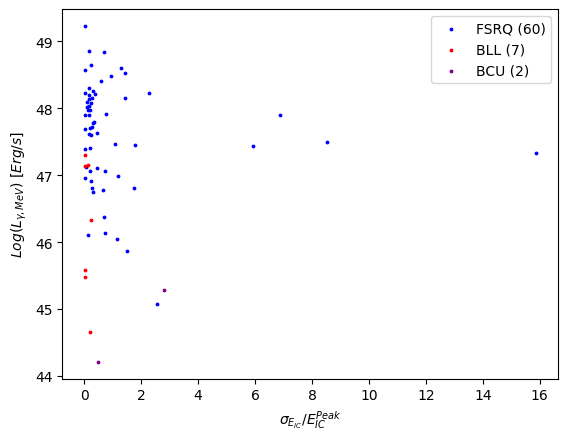

In [26]:
for i in range(len(Masked_Peaked_all)):
    IC_Peak_Energy = [float(x) for x in Masked_Peaked_all[i]['IC_Peak_Energy'].tolist()]
    IC_Peak_Energy_err = [float(x) for x in Masked_Peaked_all[i]['IC_Peak_Energy_err'].tolist()]
    
    IC_Peak_Energy_log = [np.log10(x) for x in IC_Peak_Energy]
    IC_Peak_Energy_err_log = [np.abs((1 / np.log(10)) * (x / y)) for x,y in zip(IC_Peak_Energy_err, IC_Peak_Energy)]
    
    Luminosity = Masked_Peaked_all[i]['MeV_Luminosity'].tolist()
    Luminosity_err = Masked_Peaked_all[i]['MeV_Luminosity_err'].tolist()
    
    IC_Peak_Energy_log_masked = [float(IC_Peak_Energy_log[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    IC_Peak_Energy_err_log_masked = [float(IC_Peak_Energy_err_log[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    Luminosity_err_masked = [float(Luminosity_err[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    Luminosity_masked = [float(Luminosity[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']

    Rel_err = [np.abs(x / y) for x,y in zip(IC_Peak_Energy_err_log_masked, IC_Peak_Energy_log_masked)]
    
    plt.scatter(Rel_err, Luminosity_masked, color=colors[i], label=f"{labels[i]} ({len(Luminosity_masked)})", s=3)
    plt.xlabel(r'$\sigma_{E_{IC}}/E^{Peak}_{IC}$')
    plt.ylabel(r'$Log(L_{\gamma, MeV})$ $[Erg/s]$')
    
plt.legend()
plt.savefig(outdir + 'IC_peak_rel_err_lum.png',bbox_inches='tight',dpi=300)

[[], [], [0.3568790090822015, 0.46747448398157326], [2.8663895066908704, 20.672558153339768, 1.9054010190523785, 2.537731940536643, 402.4473708189104, 0.7386272118106586, 10.868921023429394, 1.8255838567222018, 2.8687644884960584, 24.086003747158323, 0.16679262287346036], [7.9077671287239415, 4.971448194663417, 2.037252006130049, 4.256609570863369, 2.0916995003084184, 3.7132594989521945, 3.355685268138884, 1.2781677784039154, 2.512211463920226, 23.274659523538737, 42.17218863203364, 21.902363602354356, 7.7368647038873215, 67.17313551442699, 8.538758897188039, 11.37705713438626, 11.651648183038189, 13.447261338448792, 2.5661153367350553, 0.9374772932006868, 1.9745309839382583, 12.916770646556465, 9.832220671526645, 0.9360469353752812, 1.1207471851217234], [1.65385545447563, 7.286510362636892, 6.823518560486157, 13.851216355909912, 5.7757256233230425, 3.437859167000619, 4.134049832741514, 1.3936560904802031, 1.4573967891239832, 2.1083563161968475, 9.261143780479687, 1.474150172030632, 1.

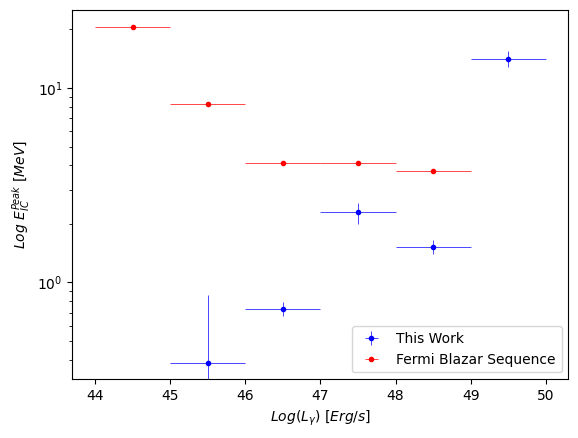

In [27]:
IC_Peak_Energy = [float(x) for x in Masked_Peaked_all[0]['IC_Peak_Energy'].tolist()]
IC_Peak_Energy_err = [float(x) for x in Masked_Peaked_all[0]['IC_Peak_Energy_err'].tolist()]

Luminosity = [float(x) for x in (Masked_Peaked_all[0]['MeV_Luminosity'].tolist())]

Luminosity_err = [float(x) for x in (Masked_Peaked_all[0]['MeV_Luminosity_err'].tolist())]

binned_luminosity = [[],[],[],[],[],[],[]]
binned_IC_peak = [[],[],[],[],[],[],[]]
binned_IC_peak_err = [[],[],[],[],[],[],[]]

Luminosity_bins = [43, 44, 45, 46, 47, 48, 49, 50]

for i in range(len(Luminosity)):
    
    for j in range(len(Luminosity_bins)-1):
        if Luminosity[i] >= Luminosity_bins[j] and Luminosity[i] < Luminosity_bins[j+1]:
            binned_luminosity[j].append((Luminosity[i]))
            binned_IC_peak[j].append((IC_Peak_Energy[i]))
            binned_IC_peak_err[j].append((IC_Peak_Energy_err[i]))
            
print(binned_IC_peak)
            
binned_luminosity = [np.mean(x) for x in binned_luminosity if len(x) > 0]
binned_IC_peak = [weighted_average(x, y) for x, y in zip(binned_IC_peak, binned_IC_peak_err) if len(x) > 0]
avg_IC_peak, avg_IC_peak_err = zip(*binned_IC_peak)
print(list(avg_IC_peak))
print(binned_luminosity)

Lum_bins = [45.5, 46.5, 47.5, 48.5, 49.5]
plt.errorbar(Lum_bins, avg_IC_peak, xerr=0.5, yerr=avg_IC_peak_err, fmt='o', color='blue', elinewidth=0.5, markersize=3, label='This Work')
plt.ylabel(r'$Log$ $E^{Peak}_{IC}$ $[MeV]$')
plt.xlabel(r'$Log(L_{\gamma})$ $[Erg/s]$')
plt.yscale('log')

Fermi_Blazar_Sequence_IC_Peak = [5e21,2e21,1e21,1e21,9e20]
Fermi_Blazar_Sequence_MeV_IC_Peak = [x * 4.1356677e-21 for x in Fermi_Blazar_Sequence_IC_Peak]
Fermi_Blazar_Sequence_Lum_bins = [44.5, 45.5, 46.5, 47.5, 48.5]

plt.errorbar(Fermi_Blazar_Sequence_Lum_bins, Fermi_Blazar_Sequence_MeV_IC_Peak, xerr=0.5, fmt='o', color='red', elinewidth=0.5, markersize=3, label='Fermi Blazar Sequence')

plt.legend()

plt.savefig(outdir + 'Blazar_Sequence_Comparison_IC_peak.png',bbox_inches='tight',dpi=300)

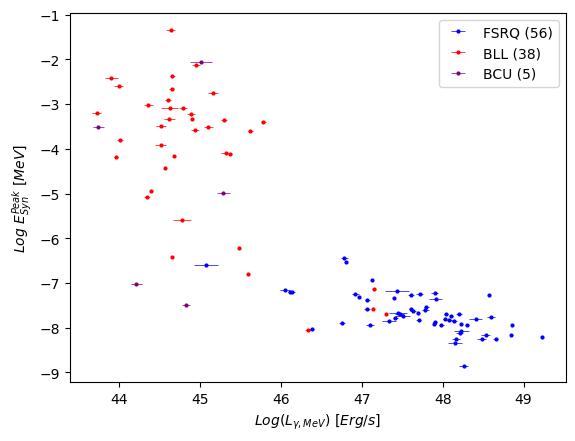

In [28]:
for i in range(len(Masked_Blazars_all)):
    Luminosity = Masked_Blazars_all[i]['MeV_Luminosity'].tolist()
    Luminosity_err = Masked_Blazars_all[i]['MeV_Luminosity_err'].tolist()
    
    Syn_peak = Masked_Blazars_all[i]['Syn_Peak_Energy'].tolist()
    
    Syn_peak_masked = [np.log10(float(Syn_peak[x])) for x in range(len(Syn_peak)) if Luminosity[x] != 'None' and Syn_peak[x] != None]
    Luminosity_err_masked = [float(Luminosity_err[x]) for x in range(len(Syn_peak)) if Luminosity[x] != 'None' and Syn_peak[x] != None]
    Luminosity_masked = [float(Luminosity[x]) for x in range(len(Syn_peak)) if Luminosity[x] != 'None' and Syn_peak[x] != None]
    
    plt.errorbar(Luminosity_masked, Syn_peak_masked, xerr=Luminosity_err_masked,label=f"{labels[i]} ({len(Luminosity_masked)})",color=colors[i],elinewidth=0.5,fmt='o',markersize=2)
    plt.ylabel(r'$Log$ $E^{Peak}_{Syn}$ $[MeV]$')
    plt.xlabel(r'$Log(L_{\gamma, MeV})$ $[Erg/s]$')
    
plt.legend()

plt.savefig(outdir + 'Sequence_Syn_peak.png',bbox_inches='tight',dpi=300)

[47.97953099372978, 48.48010051594684, 48.07899684512061, 48.13899574496449, 48.02474226696544, 46.780534066007775, 47.10153641065153, 48.16215556651803, 48.652514779255974, 48.25819273837888, 47.05887514238651, 47.78625694061755, 46.11182510674691, 48.53342118573968, 48.23065964182604, 48.85449451313631, 47.46552993586112, 47.714188763417916, 47.79824466120888, 46.05073255698709, 47.433065276483184, 46.13598291078561, 46.959449250676506, 47.63280715764801, 47.12704328114711, 46.807196781465876, 47.689956972051895, 48.19717536890897, 46.75113263913681, 47.39890488895845, 47.41433722321231, 47.896927402089034, 47.068460228728235, 48.600610872650954, 49.23201220410603, 46.379070397626634, 47.70039608432583, 47.61082485580173, 48.84906090920334, 48.29697744354572, 47.91029525678103, 48.039393625698814, 48.22555358396065, 48.57610207670975, 48.20950601302035, 47.333485927345606, 47.445085916770836, 47.607384065052685, 47.9053879889178, 46.91868792236949, 47.89835994261423, 48.4067845917315

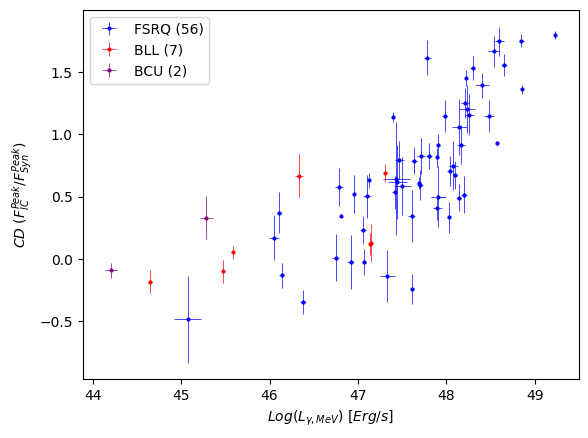

In [29]:
for i in range(len(Masked_Peaked_all)):
    Luminosity = Masked_Peaked_all[i]['MeV_Luminosity'].tolist()
    Luminosity_err = Masked_Peaked_all[i]['MeV_Luminosity_err'].tolist()
    Syn_peak_Flux = Masked_Peaked_all[i]['Syn_Peak_Energy_Flux'].tolist()
    IC_Peak_Energy_Flux = [float(x) for x in Masked_Peaked_all[i]['IC_Peak_Energy_Flux'].tolist()]
    IC_Peak_Energy_Flux_err = [float(x) for x in Masked_Peaked_all[i]['IC_Peak_Energy_Flux_err'].tolist()]
    
    Luminosity_masked = [float(Luminosity[x]) for x in range(len(Luminosity)) if Syn_peak_Flux[x] != None and Luminosity[x] !='None']
    Luminosity_err_masked = [float(Luminosity_err[x]) for x in range(len(Luminosity)) if Syn_peak_Flux[x] != None and Luminosity[x] !='None']
    Syn_peak_flux_masked = [float(Syn_peak_Flux[x]) for x in range(len(Luminosity)) if Syn_peak_Flux[x] != None and Luminosity[x] !='None']
    IC_Peak_Energy_Flux_masked = [float(IC_Peak_Energy_Flux[x]) for x in range(len(Luminosity)) if Syn_peak_Flux[x] != None and Luminosity[x] !='None']
    IC_Peak_Energy_Flux_err_masked = [float(IC_Peak_Energy_Flux_err[x]) for x in range(len(Luminosity)) if Syn_peak_Flux[x] != None and Luminosity[x] !='None']
    print(Luminosity_masked)
    print(IC_Peak_Energy_Flux_masked)
    print(Syn_peak_flux_masked)
    
    
    CD = [np.log10(x/y) for x,y in zip(IC_Peak_Energy_Flux_masked, Syn_peak_flux_masked)]
    CD_err = [(x/y) * (1/np.log(10)) for x,y in zip(IC_Peak_Energy_Flux_err_masked, IC_Peak_Energy_Flux_masked)]
    
    plt.errorbar(Luminosity_masked, CD, xerr=Luminosity_err_masked, yerr=CD_err,label=f"{labels[i]} ({len(Luminosity_masked)})",color=colors[i],elinewidth=0.5,fmt='o',markersize=2)
    plt.xlabel(r'$Log(L_{\gamma, MeV})$ $[Erg/s]$')
    plt.ylabel(r'$CD$ $(F^{Peak}_{IC}/F^{Peak}_{Syn})$')
    
    plt.legend()
    
plt.savefig(outdir + 'Sequence_CD.png',bbox_inches='tight',dpi=300)

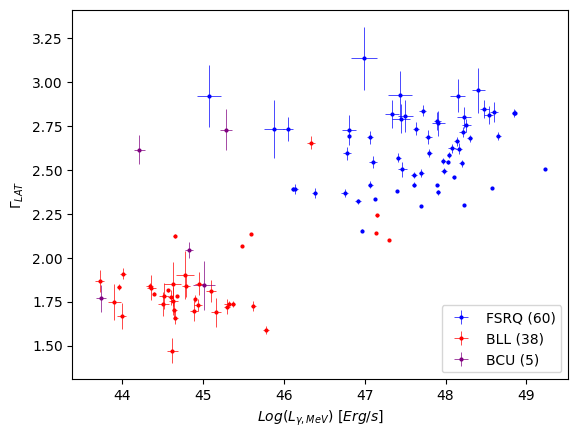

In [30]:
for i in range(len(Masked_Blazars_all)):
    Luminosity = Masked_Blazars_all[i]['MeV_Luminosity'].tolist()
    Luminosity_err = Masked_Blazars_all[i]['MeV_Luminosity_err'].tolist()
    
    LAT_index = Masked_Blazars_all[i]['LAT_PL_Index'].tolist()
    LAT_index_err = Masked_Blazars_all[i]['LAT_PL_Index_err'].tolist()
    
    LAT_index_masked = [float(LAT_index[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    LAT_index_err_masked = [float(LAT_index_err[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    Luminosity_err_masked = [float(Luminosity_err[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    Luminosity_masked = [float(Luminosity[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    
    plt.errorbar(Luminosity_masked, LAT_index_masked, xerr=Luminosity_err_masked,yerr=LAT_index_err_masked,label=f"{labels[i]} ({len(Luminosity_masked)})",color=colors[i],elinewidth=0.5,fmt='o',markersize=2)
    plt.ylabel(r'$\Gamma_{LAT}$')
    plt.xlabel(r'$Log(L_{\gamma, MeV})$ $[Erg/s]$')
    plt.legend(loc='lower right')
    
plt.savefig(outdir + 'Sequence_Gamma_index.png',bbox_inches='tight',dpi=300)
    

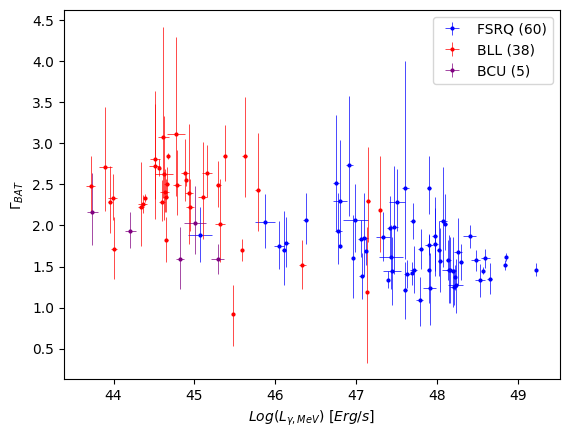

In [31]:
for i in range(len(Masked_Blazars_all)):
    Luminosity = Masked_Blazars_all[i]['MeV_Luminosity'].tolist()
    Luminosity_err = Masked_Blazars_all[i]['MeV_Luminosity_err'].tolist()
    
    BAT_index = Masked_Blazars_all[i]['BAT_Index'].tolist()
    BAT_index_err = Masked_Blazars_all[i]['BAT_Index_err'].tolist()
    
    BAT_index_masked = [float(BAT_index[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    BAT_index_err_masked = [BAT_index_err[x] for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    Luminosity_err_masked = [float(Luminosity_err[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    Luminosity_masked = [float(Luminosity[x]) for x in range(len(Luminosity)) if Luminosity[x] != 'None']
    
    BAT_index_errors = [[],[]]
    
    for x in range(len(BAT_index_masked)):
        err_lo = BAT_index_masked[x] - BAT_index_err_masked[x][0]
        err_hi = BAT_index_err_masked[x][1] - BAT_index_masked[x] 
        BAT_index_errors[0].append(err_lo)
        BAT_index_errors[1].append(err_hi)
    
    plt.errorbar(Luminosity_masked, BAT_index_masked, xerr=Luminosity_err_masked,yerr=BAT_index_errors,label=f"{labels[i]} ({len(Luminosity_masked)})",color=colors[i],elinewidth=0.5,fmt='o',markersize=2)
    plt.ylabel(r'$\Gamma_{BAT}$')
    plt.xlabel(r'$Log(L_{\gamma, MeV})$ $[Erg/s]$')
    plt.legend(loc='upper right')
    
plt.savefig(outdir + 'Sequence_X_index.png',bbox_inches='tight',dpi=300)